# Multimodal Product Catalog Search

This notebook demonstrates **text-to-image** and **image-to-image** search across a product catalog using:
- **OpenCLIP ViT-B/32** for multimodal embeddings
- **ChromaDB** for vector storage and retrieval

Run cells sequentially. Cell 2 (Indexing) only needs to run once — it's idempotent.

## 1. Setup

In [1]:
import os
import sys

# Add project root to path so we can import src modules
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from IPython.display import display, HTML

from src.metadata_parser import parse_all_images
from src.embeddings import load_model, embed_images_batch
from src.vectorstore import get_collection, index_all, get_count
from src.search import text_search, image_search, smart_search

DATASOURCES = os.path.join(PROJECT_ROOT, "datasources")
PERSIST_DIR = os.path.join(PROJECT_ROOT, ".chroma")

print(f"Project root: {PROJECT_ROOT}")
print(f"Datasources: {DATASOURCES}")

Project root: d:\dev\multimodal-embedding-rag
Datasources: d:\dev\multimodal-embedding-rag\datasources


## 2. Indexing Pipeline

Parse metadata → Generate embeddings → Store in ChromaDB.  
Skips automatically if the collection is already populated.

In [2]:
# Check if already indexed
existing_count = get_count(PERSIST_DIR)
print(f"Existing records in ChromaDB: {existing_count}")

if existing_count > 0:
    print("Collection already populated — skipping indexing.")
    print("(Delete .chroma/ folder and re-run to re-index.)")
    metadata_list = parse_all_images(DATASOURCES)
else:
    # Step 1: Parse metadata from filenames
    print("\n--- Step 1: Parsing metadata ---")
    metadata_list = parse_all_images(DATASOURCES)
    print(f"Found {len(metadata_list)} images")
    
    # Preview
    for m in metadata_list[:3]:
        print(f"  {m['sku']:15s} | {m['category']:16s} | {m['color']:12s} | {m['material']:12s} | {m['product_name'][:40]}")
    
    # Step 2: Generate embeddings
    print("\n--- Step 2: Generating embeddings ---")
    image_paths = [m["image_path"] for m in metadata_list]
    embeddings = embed_images_batch(image_paths, batch_size=16)
    print(f"Generated {len(embeddings)} embeddings, dim={len(embeddings[0])}")
    
    # Step 3: Store in ChromaDB
    print("\n--- Step 3: Indexing into ChromaDB ---")
    total = index_all(embeddings, metadata_list, persist_dir=PERSIST_DIR)
    print(f"Indexed {total} records into ChromaDB")

Existing records in ChromaDB: 364
Collection already populated — skipping indexing.
(Delete .chroma/ folder and re-run to re-index.)


## 3. Text-to-Image Search

Type a natural language query to find matching products.

In [3]:
def show_results(results, title="Search Results"):
    """Display search results as an image grid with metadata."""
    n = len(results)
    if n == 0:
        print("No results found.")
        return
    
    cols = min(n, 5)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4.5 * rows))
    fig.suptitle(title, fontsize=14, fontweight="bold")
    
    if n == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    
    for i, result in enumerate(results):
        meta = result["metadata"]
        dist = result["distance"]
        img_path = meta["image_path"]
        
        try:
            img = mpimg.imread(img_path)
            axes[i].imshow(img)
        except Exception:
            axes[i].text(0.5, 0.5, "Image not found", ha="center", va="center")
        
        label = f"{meta.get('product_name', '')[:35]}\n"
        label += f"Cat: {meta.get('category', '')} | Color: {meta.get('color', 'N/A')}\n"
        label += f"Dist: {dist:.4f}"
        axes[i].set_title(label, fontsize=8)
        axes[i].axis("off")
    
    # Hide unused axes
    for j in range(n, len(axes)):
        axes[j].axis("off")
    
    plt.tight_layout()
    plt.show()

print("show_results() helper ready.")

show_results() helper ready.


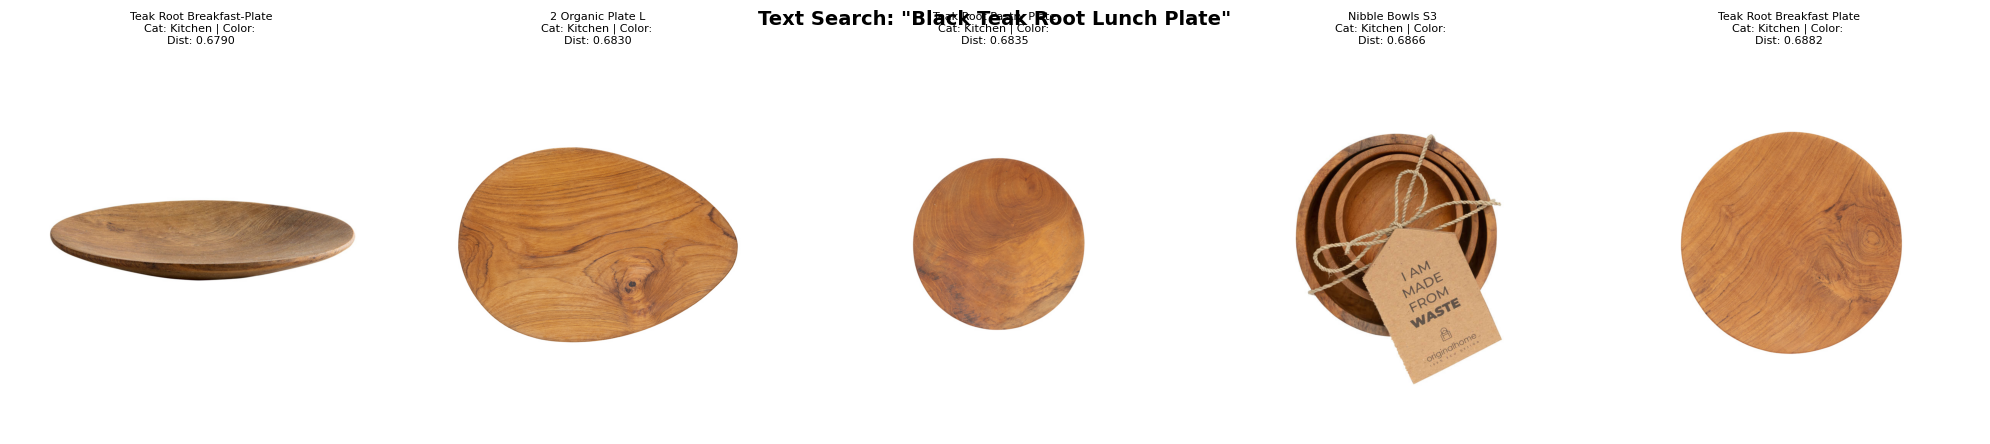

In [5]:
# --- Text-to-Image Search ---
query = "Black Teak Root Lunch Plate"  # <-- change this to any query

results = text_search(query, n_results=5, persist_dir=PERSIST_DIR)
show_results(results, title=f'Text Search: "{query}"')

## 4. Image-to-Image Search

Pick a product image and find visually similar products.

Query image: TA0005.00 Waterhyacinth Table Cork.jpg


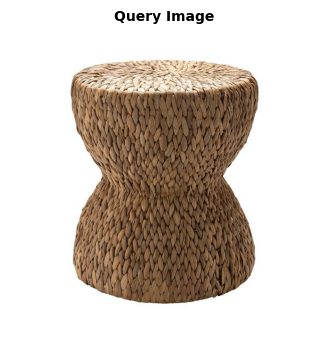

[1] ID: DI0007.00_Towel_Hangers_Set_3  |  Dist: 0.7319  |  Towel Hangers Set 3  |  File: DI0007.00 Towel Hangers Set 3.jpg
[2] ID: BP0039.01-Napking_Ring_-_Round  |  Dist: 0.7328  |  Napking Ring - Round  |  File: BP0039.01-Napking Ring - Round.jpg
[3] ID: BA0063.00_napkin_ring_organic  |  Dist: 0.7627  |  napkin ring organic  |  File: BA0063.00 napkin ring organic.jpg
[4] ID: TF0033.31_Cloth_Recycled_S_-_Off_White__striped_  |  Dist: 0.7692  |  Cloth Recycled S - Off White (striped)  |  File: TF0033.31 Cloth Recycled S - Off White (striped).jpg
[5] ID: TF0033.33_Cloth_Recy_White-Striped_Black  |  Dist: 0.7735  |  Cloth Recy White-Striped Black  |  File: TF0033.33 Cloth Recy White-Striped Black.jpg


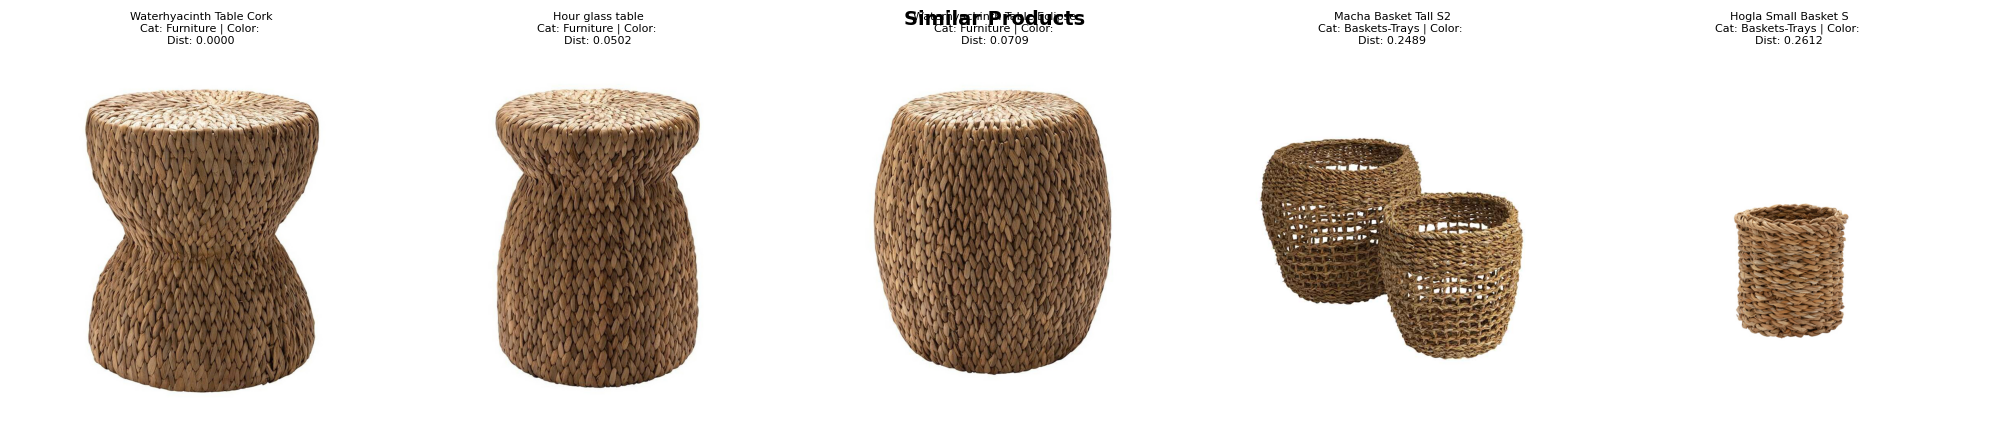

In [8]:
# --- Image-to-Image Search ---
# Pick any image from the catalog as the query
# query_image = metadata_list[0]["image_path"]  # <-- change index to pick a different image


query_image = r"D:\dev\multimodal-embedding-rag\datasources\Furniture JPG small 2022\TA0005.00 Waterhyacinth Table Cork.jpg"
print(f"Query image: {os.path.basename(query_image)}")
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.imshow(mpimg.imread(query_image))
ax.set_title("Query Image", fontsize=10, fontweight="bold")
ax.axis("off")
plt.show()


for i, r in enumerate(results):
    filename = os.path.basename(r["metadata"].get("image_path", ""))
    print(f"[{i+1}] ID: {r['id']}  |  Dist: {r['distance']:.4f}  |  {r['metadata'].get('product_name', '')}  |  File: {filename}")


results = image_search(query_image, n_results=5, persist_dir=PERSIST_DIR)
show_results(results, title="Similar Products")

## 5. Filtered Search

Combine text/image queries with metadata filters (category, color, material).

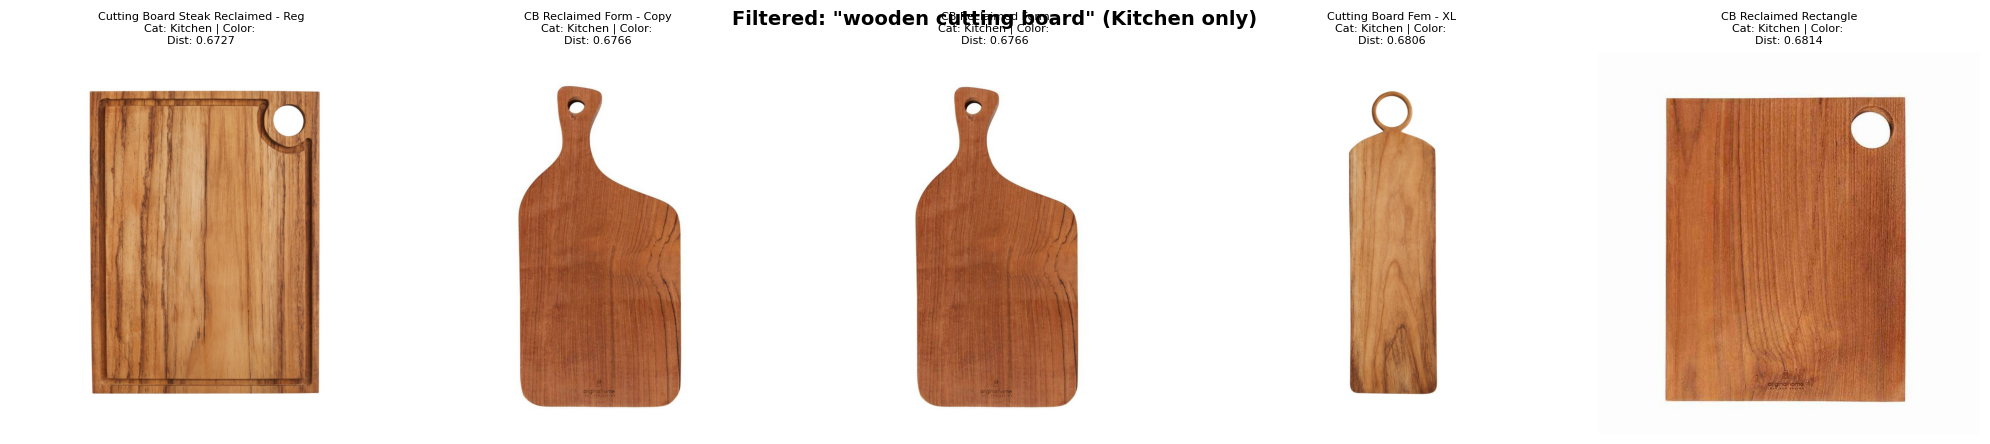

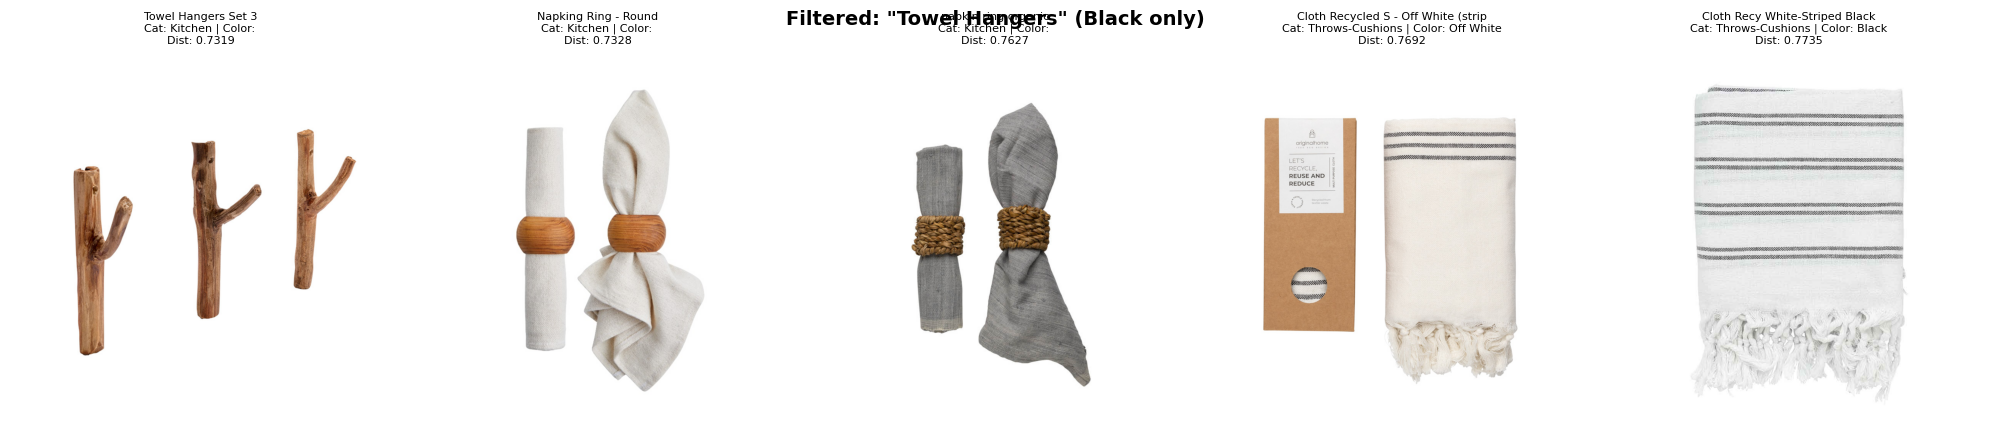

In [7]:
# --- Filtered text search: only Kitchen category ---
results = text_search(
    "wooden cutting board",
    n_results=5,
    category_filter="Kitchen",
    persist_dir=PERSIST_DIR,
)
show_results(results, title='Filtered: "wooden cutting board" (Kitchen only)')

# --- Filtered text search: black items only ---
results = text_search(
    "Towel Hangers",
    n_results=5,
    # color_filter="Brown",
    persist_dir=PERSIST_DIR,
)
show_results(results, title='Filtered: "Towel Hangers" (Black only)')

## 6. Embedding Space Visualization

Visualize the embedding space using t-SNE, colored by product category.

Visualizing 364 embeddings...


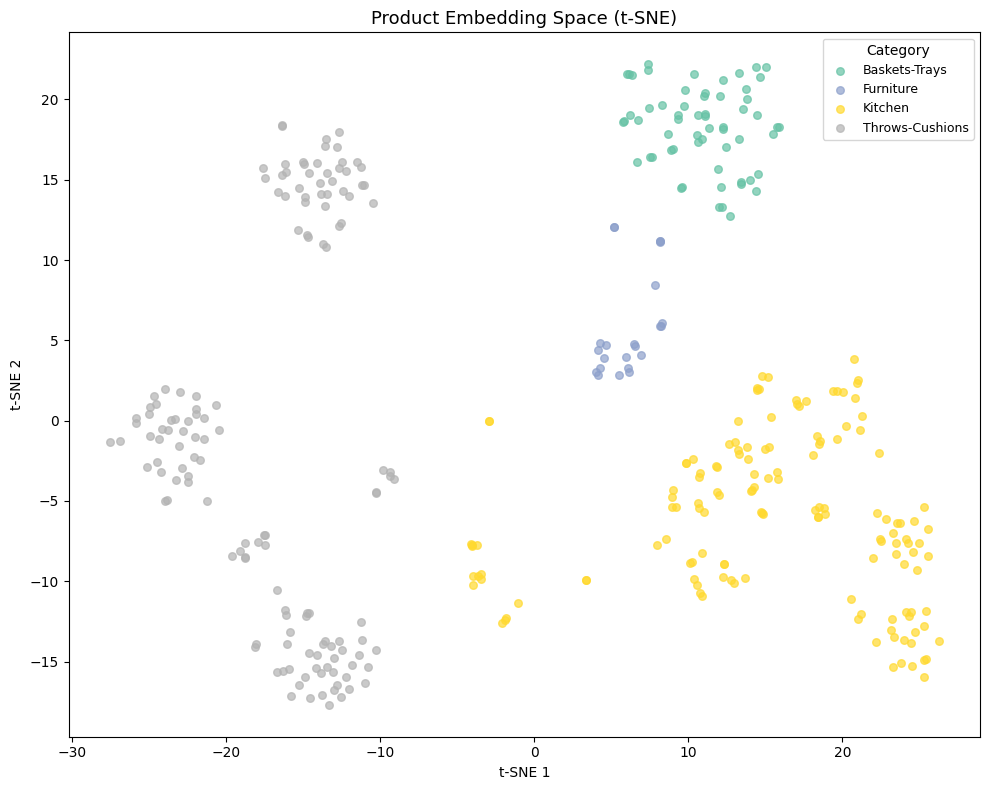

In [17]:
from sklearn.manifold import TSNE

# Fetch all embeddings from ChromaDB
collection = get_collection(PERSIST_DIR)
all_data = collection.get(include=["embeddings", "metadatas"])

all_embeddings = np.array(all_data["embeddings"])
all_categories = [m["category"] for m in all_data["metadatas"]]

print(f"Visualizing {len(all_embeddings)} embeddings...")

# t-SNE reduction to 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(all_embeddings) - 1))
coords = tsne.fit_transform(all_embeddings)

# Plot
unique_cats = sorted(set(all_categories))
colors_map = plt.cm.Set2(np.linspace(0, 1, len(unique_cats)))
cat_to_color = {cat: colors_map[i] for i, cat in enumerate(unique_cats)}

fig, ax = plt.subplots(figsize=(10, 8))
for cat in unique_cats:
    mask = [c == cat for c in all_categories]
    ax.scatter(
        coords[mask, 0], coords[mask, 1],
        label=cat, alpha=0.7, s=30, color=cat_to_color[cat]
    )
ax.legend(title="Category", fontsize=9)
ax.set_title("Product Embedding Space (t-SNE)", fontsize=13)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
plt.tight_layout()
plt.show()